In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'


In [2]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)
ocean_mask = masks.open_ocean.isin([1,2,3,4,5])
weights = np.cos(np.deg2rad(ocean_mask.lat))


In [3]:
fp = '/data/jmex/ERA5/monthly/recent/era5_t2m.nc'
t2m = xr.open_dataset(fp).sel(valid_time = slice('1979', None))


In [4]:

#change variable names
t2m = t2m.rename({'latitude':'lat', 'longitude':'lon'})
t2m = t2m.drop_vars(['number', 'expver'])


t2m = t2m.rename({'valid_time':'time'})
t2m['time'] = pd.to_datetime(t2m['time'].values.astype(str), format='%Y-%m-%d')


#aso only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

t2m = t2m.where(masks.open_ocean.isin([2,3]))
#uncomment above line for indo pac only
t = t2m.weighted(weights).mean(['lat', 'lon'])
dt = t - t.roll(year = 1)

dt = dt.drop_isel(year = 0)

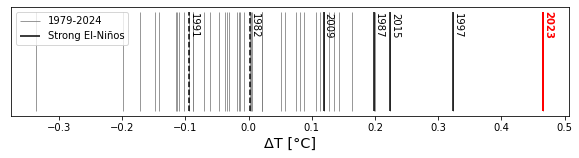

In [5]:
#Code Snipplet for BarCode-Style plots. 


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.t2m, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).t2m, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).t2m, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 
    x = dt.sel(year = y).t2m
    ax.annotate(y, (x, 0.75), rotation = 270)
        

x = dt.sel(year= 2023).t2m
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel("ΔT [°C]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.t2m")

plt.legend(loc = 'upper left')
plt.show()
#fig.savefig('Figures/FigS2.png', dpi = 600, format = 'png', bbox_inches='tight')

fig.savefig('output/FigS2_final.svg', bbox_inches='tight')
